In [13]:
print("""Unsupervised Learning discovers hidden structures or patterns in unlabeled data without human guidance while Supervised Learning is a type of machine learning where a model is trained using labeled data""")

Unsupervised Learning discovers hidden structures or patterns in unlabeled data without human guidance while Supervised Learning is a type of machine learning where a model is trained using labeled data


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [15]:
df=pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [16]:
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [17]:
x=df[["Annual Income (k$)","Spending Score (1-100)"]]

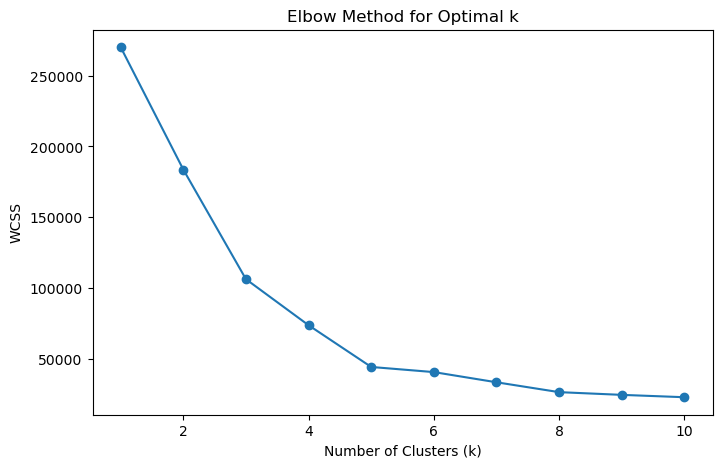

In [18]:
import warnings
warnings.filterwarnings("ignore")
wcss=[]
for i in range (1,11):
    kmeans=KMeans(n_clusters=i,init="k-means++",random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker="o")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()

In [19]:
kmeans=KMeans(n_clusters=5,init="k-means++",random_state=42)
y_kmeans=kmeans.fit_predict(x)
df["Cluster"]=y_kmeans
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


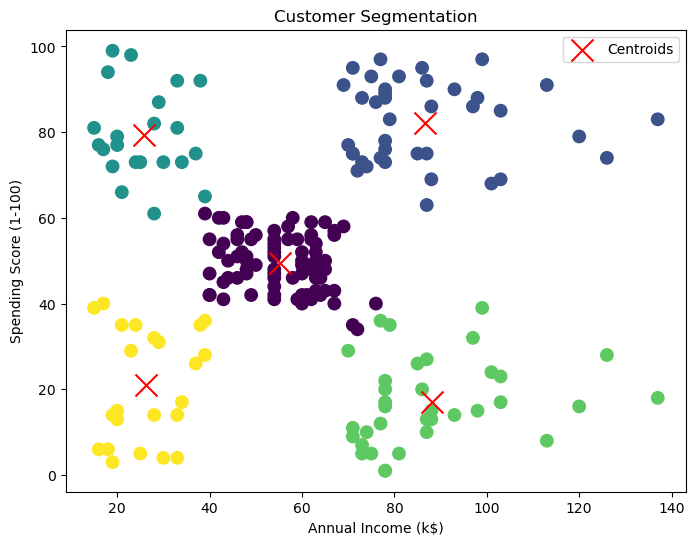

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(x.iloc[:,0],x.iloc[:,1],
            c=y_kmeans,
            cmap="viridis",
            s=80)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],
            color="red",
            marker="x",
            s=250,
            label="Centroids")
plt.title("Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [25]:
Annual_ncome=60
Spending_Score=55
new_customer=[[60,55]]
predicted_cluster=kmeans.predict(new_customer)
print("Predicted Cluster:",predicted_cluster[0])

Predicted Cluster: 0
